# 18. Gerbang "lainnya" pakai OOD (bukan retrain classifier)

**Revisi dari versi sebelumnya**: dulu kelas ke-6 "lainnya" dibangun dengan menambah data
negatif (near-miss sintesis + kode anomali OMNI + CIFAR-100) lalu retrain classifier jadi
6-kelas. Sekarang dicoba dulu pendekatan **OOD berbasis jarak embedding** — pola yang sama
persis dengan OOD frontal di notebook 10 bagian 12 (yang sudah terbukti bagus: nolak kucing,
nolak foto lateral di slot frontal) — supaya **tidak perlu data negatif sama sekali** untuk
melatih apa pun. CIFAR-100 dihapus total dari notebook ini.

Cara kerja:
1. Pakai backbone dari `view5_classifier.pt` (notebook 17) sebagai ekstraktor embedding.
2. Bangun centroid dari embedding foto **train** (gabungan 5 kelas valid) via k-means.
3. Threshold OOD dari kuantil skor **val**.
4. Near-miss sintesis + kode anomali OMNI tetap dipakai — tapi sekarang **sebagai data uji**
   untuk mengecek seberapa bagus OOD ini menangkap foto jelek/bukan-gigi, bukan buat training.

In [ ]:
import os, copy, random, shutil
from glob import glob
from collections import Counter
import numpy as np
import torch, torch.nn as nn
from torchvision import models, transforms
from PIL import Image, ImageFilter, ImageEnhance
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.expanduser('~/IOTN-AC')
IMG_DIR = os.path.join(PROJECT_ROOT, 'data', 'view5')
OMNI_IMG_DIR = os.path.expanduser('~/OMNI/data/OMNI_YOLO/images')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'models')
EVAL_DIR = os.path.join(PROJECT_ROOT, 'data', 'ood_eval'); os.makedirs(EVAL_DIR, exist_ok=True)
SPLITS = ['train', 'val', 'test']
VIEW_CLASSES_5 = ['frontal', 'lateral_kanan', 'lateral_kiri', 'maxillary', 'mandibular']

PERANGKAT = ('cuda' if torch.cuda.is_available()
             else ('mps' if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available()
                   else 'cpu'))
print('Perangkat:', PERANGKAT)

_ckpt5 = os.path.join(MODELS_DIR, 'view5_classifier.pt')
assert os.path.exists(_ckpt5), f'Model belum ada: {_ckpt5} — jalankan notebook 17 dulu.'

Perangkat: mps


## 1. Muat data 5 kelas valid + siapkan backbone dari `view5_classifier.pt`

In [ ]:
def muat_view5():
    data = {s: {'path': [], 'y': []} for s in SPLITS}
    for s in SPLITS:
        for i_kls, kls in enumerate(VIEW_CLASSES_5):
            for p in sorted(glob(os.path.join(IMG_DIR, s, kls, '*.[Jj][Pp][Gg]'))):
                data[s]['path'].append(p); data[s]['y'].append(i_kls)
    return data

DATA = muat_view5()
for s in SPLITS:
    print(s, ':', len(DATA[s]['path']), 'foto')

RATA, SIMPANG = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
tf_eval = transforms.Compose([transforms.Resize((224, 224)),
                              transforms.ToTensor(), transforms.Normalize(RATA, SIMPANG)])

def buat_resnet_cls(num_classes=len(VIEW_CLASSES_5), dropout=0.3):
    m = models.resnet18(weights=None)
    m.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(m.fc.in_features, num_classes))
    return m

_model5 = buat_resnet_cls()
_model5.load_state_dict(torch.load(_ckpt5, map_location='cpu'))

def pisah_resnet(m):
    """Pisah resnet18 (sudah fine-tuned view5): tulang (512 fitur) + kepala (klasifikasi 5-kelas)."""
    mm = copy.deepcopy(m).cpu().eval(); kepala = mm.fc; mm.fc = nn.Identity(); return mm, kepala

TULANG, KEPALA = pisah_resnet(_model5)
TULANG = TULANG.to(PERANGKAT).eval(); KEPALA = KEPALA.to(PERANGKAT).eval()
print('Backbone & kepala view5_classifier siap dipakai untuk embedding.')

train : 4008 foto
val : 1501 foto
test : 1640 foto
Backbone & kepala view5_classifier siap dipakai untuk embedding.


## 2. Bangun centroid (k-means atas embedding gabungan 5 kelas, dari data train)

In [ ]:
@torch.no_grad()
def embed(paths, bs=32):
    out = []
    for i in range(0, len(paths), bs):
        xb = torch.stack([tf_eval(Image.open(p).convert('RGB')) for p in paths[i:i + bs]]).to(PERANGKAT)
        f = TULANG(xb).cpu().numpy()
        out.append(f / (np.linalg.norm(f, axis=1, keepdims=True) + 1e-9))
    return np.concatenate(out)

def kmeans(V, k=80, it=60, seed=42):
    rng = np.random.default_rng(seed); k = min(k, len(V))
    C = V[rng.choice(len(V), k, replace=False)].copy()
    for _ in range(it):
        milik = np.argmax(V @ C.T, 1)
        for j in range(k):
            a = V[milik == j]
            if len(a): C[j] = a.mean(0) / (np.linalg.norm(a.mean(0)) + 1e-9)
    return C

E_train = embed(DATA['train']['path'])
CENT = kmeans(E_train, k=80)
print('Embedding train:', E_train.shape, '| centroid:', CENT.shape)

def ood_score(paths):
    E = embed(paths)
    return 1 - (E @ CENT.T).max(1)

Embedding train: (4008, 512) | centroid: (80, 512)


## 3. Threshold dari kuantil skor val (pola sama seperti frontal: kuantil 99% x margin 1.1)

In [ ]:
ood_val = ood_score(DATA['val']['path'])
OOD_THRESHOLD = float(np.quantile(ood_val, 0.99) * 1.1)
print(f'OOD threshold: {OOD_THRESHOLD:.4f}')
print(f'  (skor val: min {ood_val.min():.4f}  median {np.median(ood_val):.4f}  '
      f'p99 {np.quantile(ood_val, 0.99):.4f}  max {ood_val.max():.4f})')

OOD threshold: 0.1448
  (skor val: min 0.0241  median 0.0656  p99 0.1316  max 0.1642)


## 4. Siapkan data UJI (bukan training): near-miss sintesis + kode anomali OMNI

Sama seperti sebelumnya (blur, gelap/terang, crop parsial, oblique, pecah), tapi sekarang
cuma dipakai untuk **mengetes** apakah OOD ini cukup sensitif menangkap foto jelek —
bukan untuk melatih apa pun.

In [ ]:
def rusak_acak(img, rng):
    jenis = rng.choice(['blur', 'gelap', 'terang', 'crop', 'oblique', 'pecah'])
    if jenis == 'blur':
        return img.filter(ImageFilter.GaussianBlur(radius=rng.uniform(6, 12)))
    if jenis == 'gelap':
        return ImageEnhance.Brightness(img).enhance(rng.uniform(0.15, 0.35))
    if jenis == 'terang':
        return ImageEnhance.Brightness(img).enhance(rng.uniform(2.2, 3.2))
    if jenis == 'crop':
        w, h = img.size
        cw, ch = int(w * rng.uniform(0.3, 0.45)), int(h * rng.uniform(0.3, 0.45))
        x0 = rng.randint(0, max(w - cw, 1)); y0 = rng.randint(0, max(h - ch, 1))
        return img.crop((x0, y0, x0 + cw, y0 + ch)).resize((w, h))
    if jenis == 'oblique':
        sudut = rng.choice([-1, 1]) * rng.uniform(35, 55)
        return img.rotate(sudut, expand=False, fillcolor=(0, 0, 0))
    if jenis == 'pecah':
        w, h = img.size
        kecil = img.resize((max(16, w // 10), max(16, h // 10)))
        return kecil.resize((w, h))
    return img

def buat_nearmiss_uji(n, out_dir, seed=123):
    """Sumber dari TEST split saja (data yang belum pernah dilihat centroid/threshold)."""
    os.makedirs(out_dir, exist_ok=True)
    rng = random.Random(seed)
    sumber = list(DATA['test']['path']); rng.shuffle(sumber)
    hasil = []
    for i in range(min(n, len(sumber))):
        img = Image.open(sumber[i]).convert('RGB')
        img_rusak = rusak_acak(img, rng)
        p_out = os.path.join(out_dir, f'nearmiss_{i:04d}.jpg')
        img_rusak.save(p_out, quality=90)
        hasil.append(p_out)
    return hasil

NEARMISS_UJI = buat_nearmiss_uji(80, os.path.join(EVAL_DIR, 'near_miss_test'))
print(f'Near-miss uji dibuat: {len(NEARMISS_UJI)} foto -> {os.path.join(EVAL_DIR, "near_miss_test")}')

Near-miss uji dibuat: 80 foto -> /Users/rdrusdiati/IOTN-AC/data/ood_eval/near_miss_test


In [ ]:
def salin_kode_anomali_uji():
    out_dir = os.path.join(EVAL_DIR, 'anomali')
    os.makedirs(out_dir, exist_ok=True)
    hasil = []
    for split_fisik in SPLITS:
        for p in glob(os.path.join(OMNI_IMG_DIR, split_fisik, '*.JPG')):
            stem = os.path.splitext(os.path.basename(p))[0]
            kode = stem[-1]
            if kode in {'1', '2', '3', '4', '5'}:
                continue
            dst = os.path.join(out_dir, f'anomali_{os.path.basename(p)}')
            try:
                shutil.copy2(p, dst); hasil.append(dst)
            except Exception as e:
                print('  gagal salin', p, '->', e)
    return hasil

ANOMALI_UJI = salin_kode_anomali_uji()
print(f'Foto kode anomali (uji): {len(ANOMALI_UJI)} -> {os.path.join(EVAL_DIR, "anomali")}')

Foto kode anomali (uji): 20 -> /Users/rdrusdiati/IOTN-AC/data/ood_eval/anomali


## 5. Evaluasi: apakah threshold ini menolak yang seharusnya ditolak, dan menerima yang valid?

In [ ]:
def laporkan(nama, paths, label_seharusnya):
    """label_seharusnya: 'terima' (foto valid, seharusnya lolos) atau 'tolak' (seharusnya OOD)."""
    if not paths:
        print(f'{nama}: tidak ada data uji, dilewati'); return
    skor = ood_score(paths)
    ditolak = (skor > OOD_THRESHOLD)
    if label_seharusnya == 'terima':
        benar = (~ditolak).mean()
        print(f'{nama:22s} n={len(paths):4d}  seharusnya LOLOS   -> lolos beneran: {benar:6.1%}  '
              f'(median skor {np.median(skor):.4f})')
    else:
        benar = ditolak.mean()
        print(f'{nama:22s} n={len(paths):4d}  seharusnya DITOLAK -> tertolak beneran: {benar:6.1%}  '
              f'(median skor {np.median(skor):.4f})')
    return skor

print(f'(threshold = {OOD_THRESHOLD:.4f}, skor > threshold => dianggap "lainnya"/ditolak)\n')
skor_test_valid = laporkan('test set (5 kelas valid)', DATA['test']['path'], 'terima')
skor_nearmiss = laporkan('near-miss sintesis', NEARMISS_UJI, 'tolak')
skor_anomali = laporkan('kode anomali OMNI', ANOMALI_UJI, 'tolak')

print('\nCatatan: kalau near-miss/anomali banyak yang LOLOS (persentase tertolak rendah), berarti')
print('OOD ini belum cukup sensitif ke foto kualitas jelek -> pertimbangkan tambah classifier')
print('hybrid (near-miss sebagai data training, bukan cuma uji) seperti rencana awal.')

(threshold = 0.1448, skor > threshold => dianggap "lainnya"/ditolak)

test set (5 kelas valid) n=1640  seharusnya LOLOS   -> lolos beneran:  99.6%  (median skor 0.0644)
near-miss sintesis     n=  80  seharusnya DITOLAK -> tertolak beneran:  66.2%  (median skor 0.1708)
kode anomali OMNI      n=  20  seharusnya DITOLAK -> tertolak beneran:   0.0%  (median skor 0.0704)

Catatan: kalau near-miss/anomali banyak yang LOLOS (persentase tertolak rendah), berarti
OOD ini belum cukup sensitif ke foto kualitas jelek -> pertimbangkan tambah classifier
hybrid (near-miss sebagai data training, bukan cuma uji) seperti rencana awal.


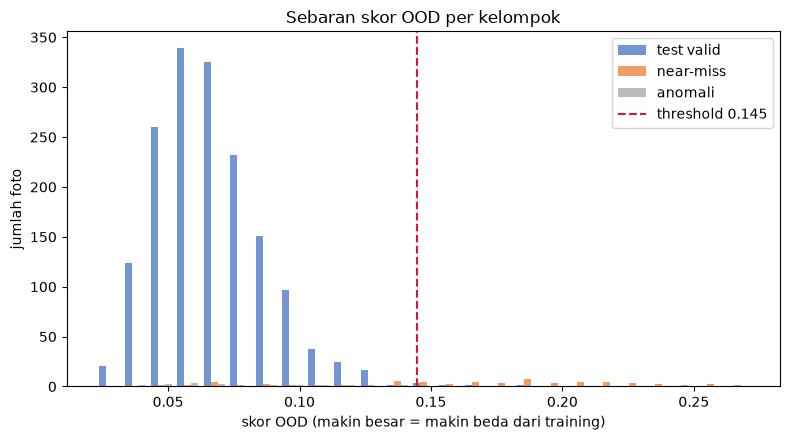

disimpan ke outputs/ood_view5_distribusi.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
kelompok = [('test valid', skor_test_valid), ('near-miss', skor_nearmiss), ('anomali', skor_anomali)]
kelompok = [(n, s) for n, s in kelompok if s is not None and len(s)]
ax.hist([s for _, s in kelompok], bins=25, label=[n for n, _ in kelompok],
        color=['#4472C4', '#ED7D31', '#A5A5A5'][:len(kelompok)], alpha=0.75)
ax.axvline(OOD_THRESHOLD, color='crimson', ls='--', label=f'threshold {OOD_THRESHOLD:.3f}')
ax.set_xlabel('skor OOD (makin besar = makin beda dari training)'); ax.set_ylabel('jumlah foto')
ax.set_title('Sebaran skor OOD per kelompok'); ax.legend()
plt.tight_layout()
_out = os.path.join(PROJECT_ROOT, 'outputs', 'ood_view5_distribusi.png')
os.makedirs(os.path.dirname(_out), exist_ok=True); fig.savefig(_out, dpi=130, bbox_inches='tight'); plt.show()
print('disimpan ke', os.path.relpath(_out, PROJECT_ROOT))

## 6. Simpan konfigurasi OOD (dipakai lagi di notebook 19 — validator)

In [ ]:
import json
cfg = dict(
    backbone_dari='view5_classifier.pt',
    view_classes=VIEW_CLASSES_5,
    k_centroid=int(CENT.shape[0]),
    centroid=np.round(CENT, 5).tolist(),
    ood_threshold=round(OOD_THRESHOLD, 6),
)
_cfg_path = os.path.join(MODELS_DIR, 'view_ood_config.json')
with open(_cfg_path, 'w') as f:
    json.dump(cfg, f, indent=1)
print('Konfigurasi OOD tersimpan ->', os.path.relpath(_cfg_path, PROJECT_ROOT))

Konfigurasi OOD tersimpan -> models/view_ood_config.json


## Uji satu foto

Cek OOD dulu (tolak kalau skornya di atas threshold); kalau lolos, baru diklasifikasi
ke salah satu dari 5 kelas pakai kepala `view5_classifier.pt`.

LOLOS OOD — skor 0.0652 <= threshold 0.1448
Prediksi kelas: lateral_kanan  (confidence 52.9%)
         frontal:  16.3%
   lateral_kanan:  52.9%  <-
    lateral_kiri:  28.8%
       maxillary:   0.8%
      mandibular:   1.2%


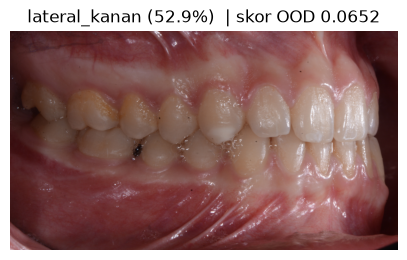

In [72]:
# ============ Uji satu foto: OOD gate + klasifikasi 5 kelas ============
GAMBAR_UJI = '/Users/rdrusdiati/IOTN-AC/data/view5/test/lateral_kiri/bite2text_F2005_3.jpg'   # <-- ganti path ini ke foto yang mau dicek
assert os.path.exists(GAMBAR_UJI), f'File tidak ditemukan: {GAMBAR_UJI}'

img = Image.open(GAMBAR_UJI).convert('RGB')
skor = ood_score([GAMBAR_UJI])[0]

if skor > OOD_THRESHOLD:
    print(f'DITOLAK — skor OOD {skor:.4f} > threshold {OOD_THRESHOLD:.4f}')
    print('Kesimpulan: "lainnya" (bukan salah satu dari 5 view valid)')
    judul = f'DITOLAK (skor OOD {skor:.4f})'
else:
    with torch.no_grad():
        logit = KEPALA(TULANG(tf_eval(img).unsqueeze(0).to(PERANGKAT)))
        prob = torch.softmax(logit, 1).cpu().numpy()[0]
    pred_i = int(prob.argmax())
    print(f'LOLOS OOD — skor {skor:.4f} <= threshold {OOD_THRESHOLD:.4f}')
    print(f'Prediksi kelas: {VIEW_CLASSES_5[pred_i]}  (confidence {prob[pred_i]:.1%})')
    for i, kls in enumerate(VIEW_CLASSES_5):
        tanda = '  <-' if i == pred_i else ''
        print(f'  {kls:>14s}: {prob[i]:>6.1%}{tanda}')
    judul = f'{VIEW_CLASSES_5[pred_i]} ({prob[pred_i]:.1%})  | skor OOD {skor:.4f}'

plt.figure(figsize=(5, 5)); plt.imshow(img); plt.axis('off'); plt.title(judul); plt.show()

## Langkah lanjutan

Lihat hasil evaluasi di bagian 5 dulu:

- Kalau **foto valid** kebanyakan lolos dan **near-miss/anomali** kebanyakan tertolak ->
  OOD ini cukup baik dipakai langsung, lanjut ke **notebook 19** (validator multi-slot).
- Kalau **near-miss** (foto gigi blur/gelap/oblique) banyak yang lolos (tidak tertolak) ->
  OOD saja belum cukup untuk kasus kualitas foto, perlu ditambah classifier hybrid yang
  dilatih dengan near-miss sebagai data training (rencana awal), bukan cuma dites di sini.